# Week 05 (Image Review)

Some exercises with image files, `Python` lists, `for` loops and `if` statements.

## Setup

Run the following 2 cells to import all necessary data, libraries and helpers.

In [1]:
# Util helpers
!wget -q "https://github.com/PSAM-5020-2026F-A/5020-utils/raw/main/src/image_utils.py" -O image_utils.py
!wget -q "https://github.com/PSAM-5020-2026F-A/Homework04/raw/main/Homework04_utils.pyc" -O Homework04_utils.pyc

# Datasets
!wget -q "https://github.com/PSAM-5020-2026F-A/5020-utils/releases/latest/download/clouds.tar.gz" -O clouds.tar.gz
!wget -q "https://github.com/PSAM-5020-2026F-A/5020-utils/releases/latest/download/flowers.tar.gz" -O flowers.tar.gz

!tar -xzf clouds.tar.gz && rm -rf clouds.tar.gz
!tar -xzf flowers.tar.gz && rm -rf flowers.tar.gz

In [2]:
import matplotlib.pyplot as plt

from os import listdir
from PIL import Image as PImage

from image_utils import get_pixels

from Homework04_utils import Homework04Utils

In [13]:
# TODO: List images
# sorted--> alphabetically
cloud_fnames = sorted([ fn for fn in listdir("./data/image/clouds") if fn.endswith (".jpg")])

flower_fnames = sorted([ fn for fn in listdir("./data/image/flowers") if fn.endswith (".png")])

print (len(cloud_fnames), len(flower_fnames))

# TODO: Separate into train/test
cloud_train = cloud_fnames[:250]
flower_train = flower_fnames[:250]

print (len(cloud_train), len(flower_train))

1628 603
250 250


In [15]:
# TODO: iterate through all images
#       get blue and/or green ratios

cloud_g_ratio = []

flower_g_ratio = []

GREEN_REF =[0, 200, 0]

# cloud images
for fn in cloud_train:
  img = PImage.open("./data/image/clouds/" + fn)
  pxs = get_pixels(img)
  g_ratio = Homework04Utils.color_ratio(pxs, GREEN_REF)
  cloud_g_ratio.append(g_ratio)

# flower images
for fn in flower_train:
  img = PImage.open("./data/image/flowers/" + fn).convert("RGB")
  pxs = get_pixels(img)
  g_ratio = Homework04Utils.color_ratio(pxs, GREEN_REF)
  flower_g_ratio.append(g_ratio)

# cloud_g_ratio[:4]

print(len(cloud_g_ratio), len(flower_g_ratio))

250 250


In [16]:
max (cloud_g_ratio), max(flower_g_ratio)

(0.10105514526367188, 0.83428955078125)

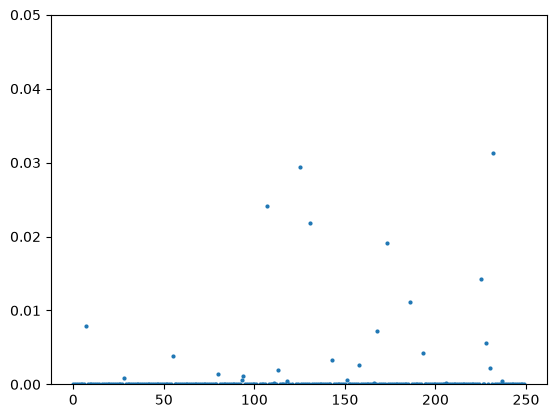

In [20]:
# TODO: plot blue and/or green ratios for both classes of images

# cloud
plt.plot(cloud_g_ratio, "o", markersize=2)
plt.ylim(0,0.05)
plt.show()

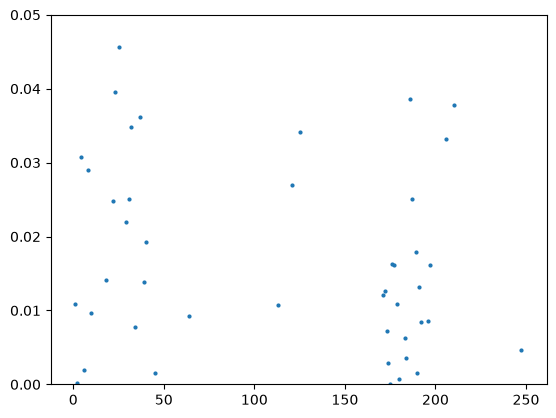

In [19]:
# flower
plt.plot(flower_g_ratio, "o", markersize=2)
plt.ylim(0,0.05)
plt.show()

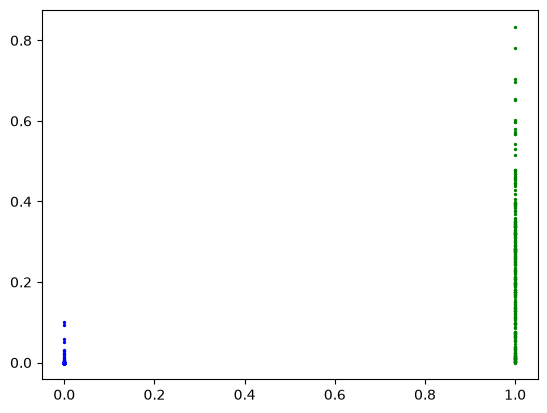

In [21]:
plt.scatter(len(cloud_g_ratio)*[0], cloud_g_ratio, c="blue", s=2)
plt.scatter(len(flower_g_ratio)*[1], flower_g_ratio, c="green", s=2)
plt.show()
